In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
df=pd.read_csv('6_top_5000_youtube_channels.csv')
df

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433
...,...,...,...,...,...,...
4995,"4,996th",B+,Uras Benlioğlu,706,2072942,441202795
4996,"4,997th",B+,HI-TECH MUSIC LTD,797,1055091,377331722
4997,"4,998th",B+,Mastersaint,110,3265735,311758426
4998,"4,999th",B+,Bruce McIntosh,3475,32990,14563764


In [6]:
#basic filtering data:-
# 1. Display Top 10 Rows of the DataSet
df.head(10)

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433
5,6th,A++,Movieclips,30243,17149705,16618094724
6,7th,A++,netd müzik,8500,11373567,23898730764
7,8th,A++,ABS-CBN Entertainment,100147,12149206,17202609850
8,9th,A++,Ryan ToysReview,1140,16082927,24518098041
9,10th,A++,Zee Marathi,74607,2841811,2591830307


In [7]:
# 2. Check Last 3 rows of the Dataset
df.tail(3)

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
4997,"4,998th",B+,Mastersaint,110,3265735,311758426
4998,"4,999th",B+,Bruce McIntosh,3475,32990,14563764
4999,"5,000th",B+,SehatAQUA,254,21172,73312511


In [8]:
# 3. Find Shape of our DataSet (number of rows & columns)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5000
Columns: 6


In [9]:
#4. Are there any missing values?
df.isnull().sum()

Rank             0
Grade            0
Channel name     0
Video Uploads    0
Subscribers      0
Video views      0
dtype: int64

In [10]:
#5. What is the statistical summary of numerical columns?
df.describe()

,Video views
count,5.000000e+03
mean,1.071449e+09
std,2.003844e+09
min,7.500000e+01
25%,1.862329e+08
50%,4.820548e+08
75%,1.124368e+09
max,4.754884e+10


In [11]:
#6 data info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rank           5000 non-null   object
 1   Grade          5000 non-null   object
 2   Channel name   5000 non-null   object
 3   Video Uploads  5000 non-null   object
 4   Subscribers    5000 non-null   object
 5   Video views    5000 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 234.5+ KB


In [13]:
#7. Remove duplicate rows
df.drop_duplicates(inplace=True)

In [29]:
#8 Convert Rank column into integer
df['Rank'] = df['Rank'].astype(str)
df['Rank'] = df['Rank'].str.replace(r'\D', '', regex=True)
df['Rank'] = df['Rank'].astype(int)

In [15]:
df.columns


Index(['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers',
       'Video views'],
      dtype='object')

In [35]:
df.dtypes


Rank               int64
Grade             object
Channel name      object
Video Uploads      int64
Subscribers      float64
Video views        int64
rank              object
dtype: object

In [33]:
#9 Convert Video Uploads into integer
df['Video Uploads'] = df['Video Uploads'].astype(str)
df['Video Uploads'] = df['Video Uploads'].str.replace(',', '')
df['Video Uploads'] = pd.to_numeric(df['Video Uploads'], errors='coerce')

In [34]:
#10 Convert Subscribers into integer
df['Subscribers'] = df['Subscribers'].astype(str)
df['Subscribers'] = df['Subscribers'].str.replace(',', '')
df['Subscribers'] = pd.to_numeric(df['Subscribers'], errors='coerce')

In [40]:
#Univariate Analysis Questions
#11 Which channel has highest subscribers?
df[df['Subscribers']==df['Subscribers'].max()]

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views,rank
1470,1471,A-,PewDiePie,3601,65995310.0,18684630003,1471


In [41]:
#12. Which channel has highest video views?
df[df['Video views']==df['Video views'].max()]

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views,rank
1,2,A++,T-Series,12661,61196302.0,47548839843,2


In [42]:
#13. Which channel uploaded most videos?
df[df['Video Uploads'] == df['Video Uploads'].max()]

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views,rank
3453,3454,B+,AP Archive,422326,746325.0,548619569,3454


In [43]:
#14. Count channels by grade
df['Grade'].value_counts()

Grade
B+      2956
A-      1024
A        963
A+        41
A++       10
           6
Name: count, dtype: int64

In [44]:
#15. Average subscribers of channels
df['Subscribers'].mean()

np.float64(2620004.1344027747)

In [45]:
#17. Average video views
df['Video views'].mean()

np.float64(1071449400.15)

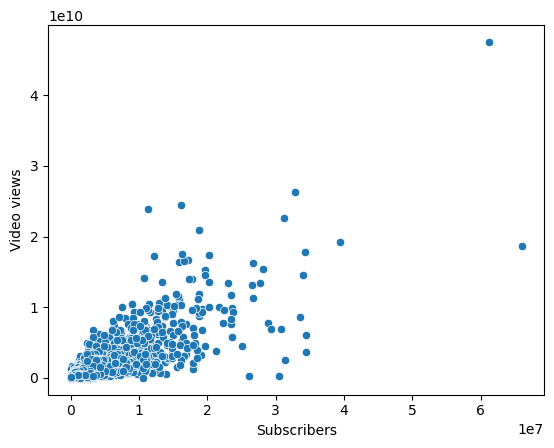

In [65]:
#Bivariate Analysis Questions
#18.Relation between subscribers and video views 
df[['Subscribers', 'Video views']].corr()
sns.scatterplot(x='Subscribers',
                y='Video views',
                data=df)

plt.show()

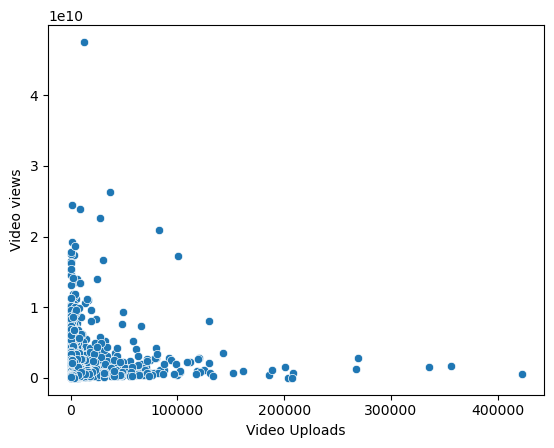

In [67]:
#19. Relation between Video Uploads and Video Views
df[['Video Uploads', 'Video views']].corr()
sns.scatterplot(x='Video Uploads',
                y='Video views',
                data=df)

plt.show()

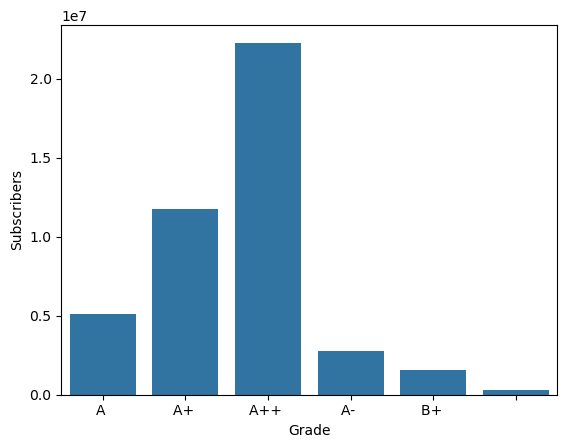

In [69]:
#20. Which Grade has highest average Subscribers?
df.groupby('Grade')['Subscribers'].mean().sort_values(ascending=False)
grade_sub = df.groupby('Grade')['Subscribers'].mean().reset_index()

sns.barplot(x='Grade',
            y='Subscribers',
            data=grade_sub)

plt.show()

In [58]:
#Multivariate Analysis Questions
#21. Compare Grade, Subscribers and Video Views together
df.groupby('Grade')[['Subscribers', 'Video views']].mean()


,Subscribers,Video views
Grade,,
A,5.107136e+06,2.361317e+09
A+,1.172695e+07,6.053121e+09
A++,2.228176e+07,2.119909e+10
A-,2.798520e+06,1.041149e+09
B+,1.535208e+06,5.265217e+08
,2.795290e+05,9.912005e+07


In [59]:
#22. Find channels with high uploads but low subscribers
df.sort_values(by=['Video Uploads', 'Subscribers'],
               ascending=[False, True]).head()

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views,rank
3453,3454,B+,AP Archive,422326,746325.0,548619569,3454
1149,1150,A-,YTN NEWS,355996,820108.0,1640347646,1150
2223,2224,B+,SBS Drama,335521,1418619.0,1565758044,2224
323,324,A,GMA News,269065,2599175.0,2786949164,324
2956,2957,B+,MLB,267649,1434206.0,1329206392,2957


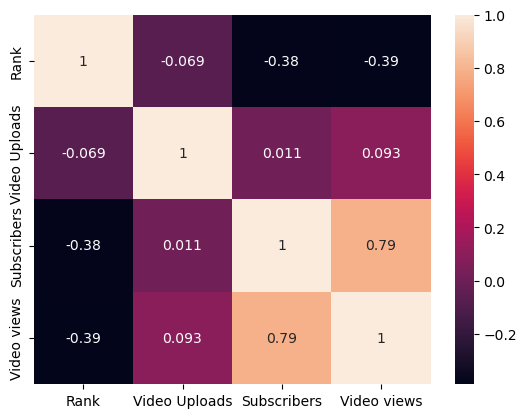

In [63]:
#23. Correlation between all numeric columns
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True),
            annot=True)
plt.show()